<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Aula_02/Pratica2Quest%C3%A3o6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando handel.wav de https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_02/Sinais_Usados/handel.wav ...
Download concluido.

Sinal original: fs = 8192 Hz, N = 73113 amostras, duracao = 8.925 s

L = 2: fs_novo = 16384 Hz, N_novo = 146226 amostras, Nyquist_novo = 8192 Hz
L = 4: fs_novo = 32768 Hz, N_novo = 292452 amostras, Nyquist_novo = 16384 Hz
L = 8: fs_novo = 65536 Hz, N_novo = 584904 amostras, Nyquist_novo = 32768 Hz


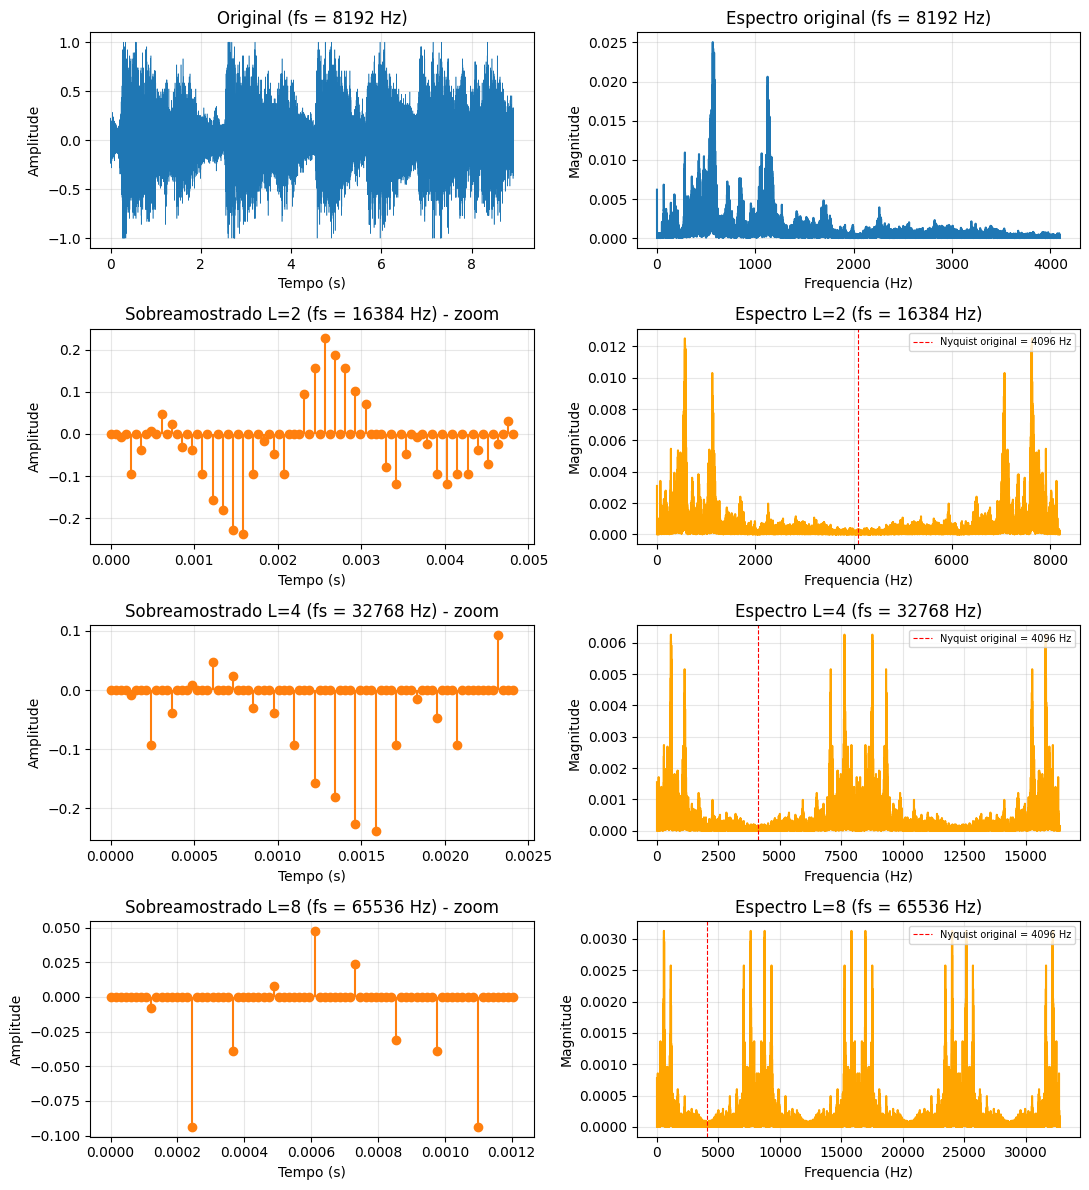

Reproduzindo o audio na frequencia de amostragem original:


--------------------------------------------------
Reproduzindo o audio sobreamostrado por L=2 (fs = 16384 Hz):


--------------------------------------------------
Reproduzindo o audio sobreamostrado por L=4 (fs = 32768 Hz):


--------------------------------------------------
Reproduzindo o audio sobreamostrado por L=8 (fs = 65536 Hz):


--------------------------------------------------


In [ ]:
"""
Questao 6 - Sobreamostragem de um sinal discreto x[n]

Definicao:
             { x[n/L] ,  n = mL, m em Z
    y[n] =   {
             { 0       ,  caso contrario

    Ou seja, a sobreamostragem (upsampling) consiste em inserir L-1 zeros
    entre cada duas amostras consecutivas do sinal original. O sinal
    resultante y[n] tem N*L amostras (N = numero de amostras de x[n]),
    e sua nova frequencia de amostragem efetiva passa a ser fs*L.

Objetivo:
    (a) Criar uma funcao para realizar a sobreamostragem de um sinal discreto
    (b) Aplicar a sobreamostragem ao audio handel.wav para L em {2, 4, 8}
    (c) Calcular o espectro de cada sinal sobreamostrado (calculate_spectrum)
    (d) Ouvir os sinais sobreamostrados
    (e) Comentar os resultados obtidos
"""

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import IPython.display as ipd


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum (mesma das questoes anteriores)
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.
    Retorna freqs (Hz, parte positiva 0 a fs/2) e mag (magnitude normalizada).
    """
    N = len(x)
    X = np.fft.fft(x)
    freqs_completo = np.fft.fftfreq(N, d=1/fs)
    metade = N // 2
    freqs = freqs_completo[:metade]
    mag = (2.0 / N) * np.abs(X[:metade])
    return freqs, mag


# ---------------------------------------------------------------------------
# (a) Funcao de sobreamostragem: insercao de L-1 zeros entre amostras
# ---------------------------------------------------------------------------
def sobreamostrar(x, L):
    """
    Realiza a sobreamostragem (upsampling) de um sinal discreto x[n],
    inserindo L-1 zeros entre cada duas amostras consecutivas:

        y[n] = x[n/L],  se n = mL (m inteiro)
        y[n] = 0,       caso contrario

    Parametros
    ----------
    x : array_like
        Sinal discreto original, com N amostras.
    L : int
        Fator de sobreamostragem (inteiro >= 1).

    Retorna
    -------
    y : ndarray
        Sinal sobreamostrado, com N*L amostras.
    """
    N = len(x)
    y = np.zeros(N * L)   # vetor de saida, inicialmente todo zero

    # Coloca cada amostra original x[m] na posicao n = m*L de y,
    # deixando as L-1 posicoes seguintes como zero
    y[::L] = x

    return y


# ---------------------------------------------------------------------------
# Leitura do arquivo handel.wav (mesmo procedimento das questoes anteriores)
# ---------------------------------------------------------------------------
usar_colab = True   # mude para False se estiver rodando localmente com o repo clonado

if usar_colab:
    url = ("https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/"
           "main/Aula_02/Sinais_Usados/handel.wav")
    caminho_arquivo = "handel.wav"
    if not os.path.exists(caminho_arquivo):
        print(f"Baixando {caminho_arquivo} de {url} ...")
        urllib.request.urlretrieve(url, caminho_arquivo)
        print("Download concluido.\n")
else:
    caminho_arquivo = "Aula_02/Sinais_Usados/handel.wav"

fs, x = wavfile.read(caminho_arquivo)

if x.ndim > 1:
    x = x[:, 0]

x = x.astype(np.float64)
x = x / np.max(np.abs(x))

N = len(x)
print(f"Sinal original: fs = {fs} Hz, N = {N} amostras, duracao = {N/fs:.3f} s\n")


# ---------------------------------------------------------------------------
# (b) e (c) Sobreamostragem para L = 2, 4, 8 + calculo do espectro de cada um
# ---------------------------------------------------------------------------
fatores_L = [2, 4, 8]
sinais_sobreamostrados = {}   # guarda y[n] e fs_novo para cada L (usado no item d)

fig, eixos = plt.subplots(len(fatores_L) + 1, 2, figsize=(11, 12))

# --- Primeira linha: sinal original, para referencia/comparacao ---
freqs_orig, mag_orig = calculate_spectrum(x, fs)
t_orig = np.arange(N) / fs

eixos[0, 0].plot(t_orig, x, linewidth=0.4)
eixos[0, 0].set_title(f"Original (fs = {fs} Hz)")
eixos[0, 0].set_xlabel("Tempo (s)")
eixos[0, 0].set_ylabel("Amplitude")
eixos[0, 0].grid(True, alpha=0.3)

eixos[0, 1].plot(freqs_orig, mag_orig)
eixos[0, 1].set_title(f"Espectro original (fs = {fs} Hz)")
eixos[0, 1].set_xlabel("Frequencia (Hz)")
eixos[0, 1].set_ylabel("Magnitude")
eixos[0, 1].grid(True, alpha=0.3)

# --- Linhas seguintes: um sinal sobreamostrado para cada L ---
for i, L in enumerate(fatores_L, start=1):

    # (a) Aplica a sobreamostragem: insere L-1 zeros entre as amostras
    y = sobreamostrar(x, L)

    # A nova frequencia de amostragem efetiva sobe de fs para fs*L
    fs_novo = fs * L

    # Guarda para uso posterior (item d - ouvir os audios)
    sinais_sobreamostrados[L] = (y, fs_novo)

    # (c) Calcula o espectro do sinal sobreamostrado
    freqs, mag = calculate_spectrum(y, fs_novo)

    t_y = np.arange(len(y)) / fs_novo

    print(f"L = {L}: fs_novo = {fs_novo:.0f} Hz, "
          f"N_novo = {len(y)} amostras, "
          f"Nyquist_novo = {fs_novo/2:.0f} Hz")

    # Plot do sinal sobreamostrado no tempo (zoom nas primeiras amostras,
    # para conseguir enxergar os zeros inseridos entre as amostras originais)
    amostras_zoom = min(80, len(y))
    eixos[i, 0].stem(t_y[:amostras_zoom], y[:amostras_zoom],
                      basefmt=" ", linefmt='C1-', markerfmt='C1o')
    eixos[i, 0].set_title(f"Sobreamostrado L={L} (fs = {fs_novo:.0f} Hz) - zoom")
    eixos[i, 0].set_xlabel("Tempo (s)")
    eixos[i, 0].set_ylabel("Amplitude")
    eixos[i, 0].grid(True, alpha=0.3)

    # Plot do espectro do sinal sobreamostrado
    eixos[i, 1].plot(freqs, mag, color='orange')
    eixos[i, 1].set_title(f"Espectro L={L} (fs = {fs_novo:.0f} Hz)")
    eixos[i, 1].set_xlabel("Frequencia (Hz)")
    eixos[i, 1].set_ylabel("Magnitude")
    # Marca onde ficava a banda ocupada pelo sinal original (fs/2), para
    # visualizar as replicas espectrais (imagens) geradas pela sobreamostragem
    eixos[i, 1].axvline(fs/2, color='r', linestyle='--', linewidth=0.8,
                         label=f"Nyquist original = {fs/2:.0f} Hz")
    eixos[i, 1].legend(loc="upper right", fontsize=7)
    eixos[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("espectros_sobreamostragem.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# (d) Ouvir os sinais sobreamostrados
# ---------------------------------------------------------------------------
# Reproduz o audio original e cada versao sobreamostrada (L = 2, 4, 8),
# cada uma no seu proprio fs_novo (fs original * L), direto no notebook.

print("Reproduzindo o audio na frequencia de amostragem original:")
ipd.display(ipd.Audio(x, rate=fs, autoplay=False))
print('-' * 50)

for L in fatores_L:
    y, fs_novo = sinais_sobreamostrados[L]
    print(f"Reproduzindo o audio sobreamostrado por L={L} (fs = {fs_novo:.0f} Hz):")
    ipd.display(ipd.Audio(y, rate=fs_novo, autoplay=False))
    print('-' * 50)

Os resultados evidenciam claramente o efeito clássico da sobreamostragem por inserção de zeros: a criação de réplicas espectrais (imagens) do sinal original.

Domínio do tempo (zoom) — os gráficos em stem mostram exatamente o que a fórmula do enunciado descreve: entre cada amostra original (não-nula), há L−1 zeros inseridos. Isso fica visualmente evidente: para L=2, há 1 zero entre amostras; para L=4, 3 zeros; para L=8, 7 zeros. O padrão "esparso" fica cada vez mais evidente à medida que L cresce, já que a mesma quantidade de informação (as amostras originais) fica cada vez mais "diluída" no tempo, embora a taxa de amostragem (fs_novo = fs·L) também cresça na mesma proporção, mantendo a duração total do sinal inalterada.

Domínio da frequência — surgimento de réplicas espectrais — este é o resultado mais importante: o espectro original ocupava a faixa de 0 a ~4096 Hz (Nyquist original). Após a sobreamostragem:

L = 2: além da réplica original (0–4096 Hz), surge uma nova réplica espelhada próxima de 8192 Hz (a nova metade da banda, já que fs_novo = 16384 Hz). No gráfico, é visível o "bloco" de energia repetido perto de 7000–8000 Hz, espelhando o formato do espectro original.

L = 4: agora aparecem 3 réplicas adicionais do espectro original, distribuídas ao longo da nova faixa (até 32768 Hz), cada uma centrada em múltiplos de fs (8192 Hz, 16384 Hz, 24576 Hz...). O padrão fica visualmente parecido com "cópias" do espectro original se repetindo periodicamente.

L = 8: o efeito é ainda mais evidente — 7 réplicas do espectro original aparecem espalhadas por toda a nova banda (até 65536 Hz), formando um padrão periódico bem definido de "blocos" repetidos de energia.

Esse comportamento é exatamente o esperado pela teoria: inserir zeros no domínio do tempo é matematicamente equivalente, no domínio da frequência, a replicar o espectro original periodicamente ao longo de toda a nova banda (0 a fs_novo/2), gerando L−1 réplicas (imagens) adicionais além da réplica original em banda base.

Relação com o áudio ouvido (item d) — apesar dessas réplicas espectrais indesejadas, o áudio sobreamostrado deve soar perceptualmente igual ao original, na região de frequências audíveis mais baixas — e de fato os players mostram a mesma duração (0:08) em todos os casos, pois a sobreamostragem não altera a duração temporal do sinal nem distorce a informação já existente (diferente da subamostragem, que causava perda de informação por aliasing). O que a sobreamostragem faz é apenas adicionar conteúdo espectral espúrio em frequências altas (as réplicas), que originalmente não existia no sinal — mas que, se não for filtrado, pode gerar ruído de alta frequência ou artefatos ao converter o sinal de volta para analógico.

Conclusão geral — o experimento demonstra que a sobreamostragem por inserção de zeros, por si só, não adiciona informação nova ao sinal — ela apenas aumenta a taxa de amostragem, criando réplicas espectrais indesejadas do conteúdo original espalhadas ao longo da nova banda de frequências. Para que a sobreamostragem seja útil na prática (por exemplo, para interpolação real do sinal, sem esses artefatos), é necessário aplicar um filtro passa-baixas (com corte na antiga frequência de Nyquist, fs/2) logo após a inserção dos zeros — esse filtro elimina as réplicas espectrais indesejadas, deixando apenas a réplica original em banda base, suavizando as transições entre as amostras reais e completando os "buracos" (zeros) com valores interpolados corretamente, em vez de zeros abruptos.